In [120]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [121]:
df_results = pd.read_json('serp_fc_results.jsonl', lines=True)

In [122]:
# Add content length columns

BASE = Path("../samples/ymyl_29000/res_20250723_n100").resolve()
SCRAPED_CSV = BASE / "_scraped.csv"

df_scraped = pd.read_csv(SCRAPED_CSV)

df_results = df_results.merge(df_scraped[['url', 'content']], on='url', how='left')

df_results['content_char_count'] = df_results['content'].fillna('').str.len()
df_results['content_word_count'] = df_results['content'].fillna('').str.split().str.len()
df_results['content_sentence_count'] = df_results['content'].fillna('').str.count(r'[.!?]') + 1

In [140]:
# Show explanations with keyword
keyword = "navigation"

from collections import Counter

website_nav_explanations = Counter(
    r["explanation"]
    for x in df_results["checker_response"]
    if isinstance(x, dict)
    for r in x.get("data", {}).get("results", [])
    if keyword in r.get("explanation", "").lower()
)

for expl, count in website_nav_explanations.most_common(10):
    print(f"{count:>4} × {expl}")

  15 × The text is a repeated website navigation and menu content, not a factual statement about BMO credit cards or digital wallets.
  13 × This repeats the same navigation and menu text and is not a factual statement about Freddie Mac tools or systems.
   9 × The text is a repeated navigation and menu content from BMO's website, not factual information about GIC interest rates.
   9 × The text is repeated navigation content from BMO Canada website, not factual information about insurance or GIC rates.
   9 × The text is a repeated website navigation and category listing, not a factual statement about Amazon services or subsidiaries.
   8 × The text is a repeated website navigation content without factual claims about GIC interest rates.
   8 × This is repeated website navigation text, not a factual statement about vasculitis types.
   8 × This is a repeated Amazon website navigation text, not a factual statement about Amazon services or subsidiaries.
   8 × This is a repeated navigat

In [124]:
# Count T/F claims for each document

df_results['true_count'] = df_results['checker_response'].apply(
    lambda x: sum(r.get('classification') == 'True'
                  for r in (x.get('data', {}).get('results', []) if isinstance(x, dict) else []))
)

df_results['false_count'] = df_results['checker_response'].apply(
    lambda x: sum(
        r.get('classification') == 'False'
        for r in (x.get('data', {}).get('results', []) if isinstance(x, dict) else [])
        if "website navigation" not in r.get("explanation", "").lower()
    )
)

In [125]:
ai_results = df_results[df_results['ai_class'] == 'AI']
human_results = df_results[df_results['ai_class'] == 'Human']

ai_count = len(ai_results)
human_count = len(human_results)
total_count = len(df_results)

print('AI count:\t', ai_count)
print('Human count:\t', human_count)
print('---')
print('Total count:\t', total_count)

print()
print('AI share:\t', f'{(ai_count / total_count) * 100:.4f}%')

AI count:	 2209
Human count:	 19565
---
Total count:	 21774

AI share:	 10.1451%


In [126]:
# Group by ai_class and aggregate counts
fact_stats = (
    df_results.groupby('ai_class')[['true_count', 'false_count']]
    .agg(['sum', 'mean', 'median'])
)

print(fact_stats)

         true_count                   false_count                 
                sum       mean median         sum      mean median
ai_class                                                          
AI            29135  13.189226   13.0        2467  1.116795    1.0
Human        203086  10.380066   10.0       23327  1.192282    1.0


In [127]:
def get_val_stats(df: pd.DataFrame, value_fn) -> dict:
    """
    Returns dict(min, max, mean, median, count) for values derived from df using value_fn(row).
    """
    vals = df.apply(value_fn, axis=1)
    vals = vals.replace([np.inf, -np.inf], np.nan).dropna()
    if len(vals) == 0:
        return {"min": np.nan, "max": np.nan, "mean": np.nan, "median": np.nan, "count": 0}
    return {
        "min": float(vals.min()),
        "max": float(vals.max()),
        "mean": float(vals.mean()),
        "median": float(vals.median()),
        "count": int(len(vals)),
    }

In [128]:
numerators = ["true_count", "false_count"]
denominators = ["content_char_count", "content_word_count", "content_sentence_count"]

rows = []
for group_name, group_df in [("AI", ai_results), ("Human", human_results)]:
    for num in numerators:
        for den in denominators:
            stats = get_val_stats(
                group_df,
                # freeze loop vars to avoid late binding
                lambda row, c=num, b=den: (row[c] / row[b]) if (pd.notna(row[b]) and row[b] > 0) else np.nan
            )
            rows.append({
                "group": group_name,
                "numerator": num,
                "denominator": den,
                **stats
            })

stats_df = pd.DataFrame(rows)
print(stats_df)

    group    numerator             denominator  min        max      mean  \
0      AI   true_count      content_char_count  0.0   0.008400  0.002682   
1      AI   true_count      content_word_count  0.0   0.053777  0.017470   
2      AI   true_count  content_sentence_count  0.0   1.727273  0.361166   
3      AI  false_count      content_char_count  0.0   0.003002  0.000229   
4      AI  false_count      content_word_count  0.0   0.018337  0.001471   
5      AI  false_count  content_sentence_count  0.0   2.500000  0.032104   
6   Human   true_count      content_char_count  0.0   0.044286  0.002327   
7   Human   true_count      content_word_count  0.0   0.348315  0.015082   
8   Human   true_count  content_sentence_count  0.0  74.000000  0.399828   
9   Human  false_count      content_char_count  0.0   0.011628  0.000290   
10  Human  false_count      content_word_count  0.0   0.102941  0.001893   
11  Human  false_count  content_sentence_count  0.0  45.000000  0.068312   

      media

In [129]:
# --- 3) Print a table for FALSE ratios only (rows = content counts; sub-rows = AI/Human; cols = min,max,mean,median)
false_df = stats_df[stats_df["numerator"] == "false_count"].copy()

# Make a readable mapping for row labels if you prefer
nice_den = {
    "content_char_count": "per Character",
    "content_word_count": "per Word",
    "content_sentence_count": "per Sentence",
}
false_df["row_group"] = false_df["denominator"].map(nice_den)

# Build a small print table for each denominator with AI/Human rows
print("\n=== FALSE COUNT RATIOS: AI vs Human (min / max / mean / median) ===")
for den_key in denominators:
    block = false_df[false_df["denominator"] == den_key]
    block = block.set_index("group")[["min", "max", "mean", "median"]].sort_index()
    print(f"\n--- false_count / {den_key} ---")
    print(block.to_string(float_format=lambda x: f"{x:.8f}"))


=== FALSE COUNT RATIOS: AI vs Human (min / max / mean / median) ===

--- false_count / content_char_count ---
             min        max       mean     median
group                                            
AI    0.00000000 0.00300180 0.00022863 0.00020000
Human 0.00000000 0.01162791 0.00029020 0.00020000

--- false_count / content_word_count ---
             min        max       mean     median
group                                            
AI    0.00000000 0.01833741 0.00147068 0.00122699
Human 0.00000000 0.10294118 0.00189264 0.00123305

--- false_count / content_sentence_count ---
             min         max       mean     median
group                                             
AI    0.00000000  2.50000000 0.03210389 0.02173913
Human 0.00000000 45.00000000 0.06831194 0.02173913


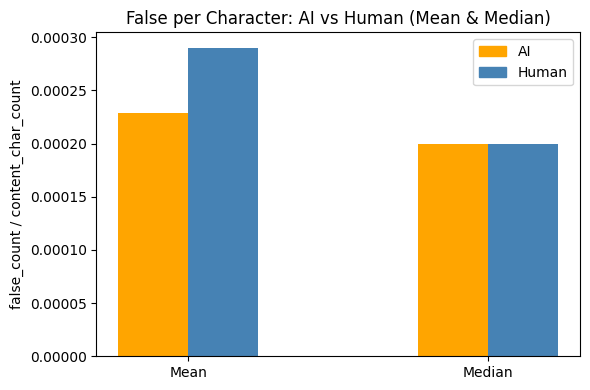

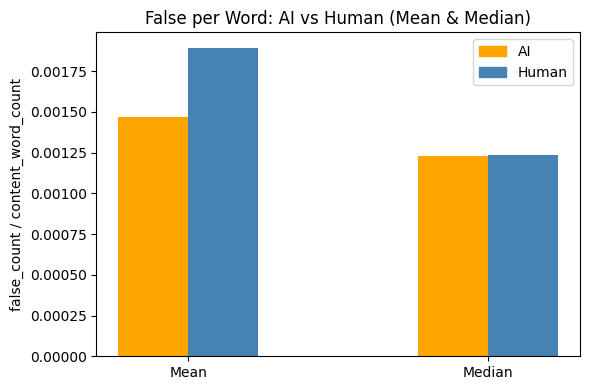

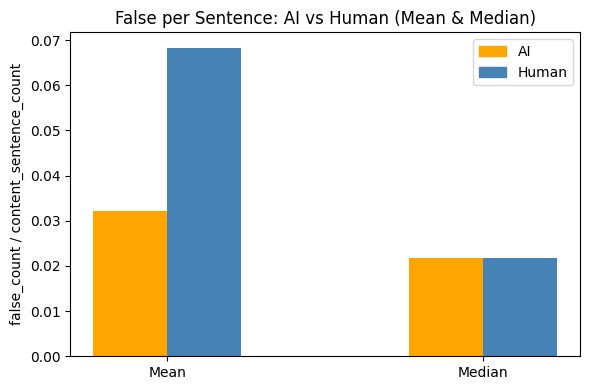

In [130]:
def plot_ai_human_mean_median(false_stats_df, denominator, title=None):
    """
    Creates a bar plot with 4 bars:
      Group 1 (Mean):   AI mean (orange), Human mean (blue)
      Group 2 (Median): AI median (orange), Human median (blue)
    """
    sub = false_stats_df[false_stats_df["denominator"] == denominator]
    ai = sub[sub["group"] == "AI"].iloc[0]
    hu = sub[sub["group"] == "Human"].iloc[0]

    means = [ai["mean"], hu["mean"]]
    medians = [ai["median"], hu["median"]]

    x0, x1 = 0, 1.5
    width = 0.35

    plt.figure(figsize=(6, 4))

    # Colors: AI = orange, Human = blue
    ai_color = "orange"
    human_color = "steelblue"

    # Mean cluster (AI left, Human right)
    plt.bar([x0 - width/2, x0 + width/2], means, width=width,
            color=[ai_color, human_color], label=["AI Mean", "Human Mean"])
    # Median cluster (AI left, Human right)
    plt.bar([x1 - width/2, x1 + width/2], medians, width=width,
            color=[ai_color, human_color], label=["AI Median", "Human Median"])

    plt.xticks([x0, x1], ["Mean", "Median"])
    plt.ylabel(f"false_count / {denominator}")
    plt.title(title or f"False / {denominator}: AI vs Human (Mean & Median)")

    # Build custom legend manually so AI/ Human show once
    plt.legend(handles=[
        plt.Rectangle((0,0),1,1,color=ai_color, label="AI"),
        plt.Rectangle((0,0),1,1,color=human_color, label="Human")
    ])

    plt.tight_layout()
    plt.show()

# Make the 3 requested plots (for false_count only)
for den, nice in [
    ("content_char_count", "False per Character"),
    ("content_word_count", "False per Word"),
    ("content_sentence_count", "False per Sentence"),
]:
    plot_ai_human_mean_median(
        false_df,
        denominator=den,
        title=f"{nice}: AI vs Human (Mean & Median)"
    )

In [131]:
# Compute mean sentence length per row
df_results['mean_sentence_len'] = (
    df_results['content'].fillna('').str.split().str.len() / df_results['content_sentence_count']
)

# Group by AI/Human and compute mean of mean_sentence_len
mean_sentence_len = df_results.groupby('ai_class')['mean_sentence_len'].mean()
print('Mean sentence length per', mean_sentence_len)


Mean sentence length per ai_class
AI       21.972051
Human    34.696454
Name: mean_sentence_len, dtype: float64
